# Configuration

In [ ]:
# File paths
INPUT_MARKET_CAP_WEIGHTS_PATH = '../Market Caps/Final/coalesced_market_cap_weights.csv'
INPUT_BOND_WEIGHTS_PATH = './Processed/bond_weights.csv'
INPUT_EQUITIES_UNIVERSE_PATH = './Processed/equities_universe.csv'
INPUT_BONDS_UNIVERSE_PATH = './Processed/bonds_universe.csv'
INPUT_JST_RETURN_DATA_PATH = './Processed/jst_return_data.csv'
INPUT_DOMESTIC_MASK_PATH = './Processed/domestic_mask.csv'
INPUT_ASSET_CLASS_CONFIGS_PATH = './Source/asset_class_configs.yml'
OUTPUT_COMBINED_RETURN_DATA_PATH = './Processed/combined_return_data_by_country.csv'
OUTPUT_SUMMARY_STATS_PATH = './Processed/combined_return_data_by_country_summary_stats.csv'
OUTPUT_ASSET_CLASS_RETURNS_PATH = './Processed/asset_class_returns.csv'

# Plot parameters
PLOT_YEAR_MIN = 1870
PLOT_YEAR_MAX = 2020
FILTER_YEAR_MIN = 1900
FIGSIZE_WEIGHTS = (14, 10)
FIGSIZE_CUM_RETURNS = (14, 12)
GRID_ALPHA = 0.3
STACKPLOT_LINE_WIDTH = 0.5
FONTSIZE_LABEL = 12
FONTSIZE_TITLE = 14
FONTSIZE_LEGEND = 9
TITLE_PAD = 15

# Quality check tolerances
WEIGHT_SUM_TOLERANCE_MIN = 0.999
WEIGHT_SUM_TOLERANCE_MAX = 1.001

# Asset class definitions
ASSET_CLASSES = ["Equities", "Bonds", "Bills", "CPI"]
RETURN_SUBTYPES = ["foreign_tr_hedged", "foreign_tr_unhedged", "domestic_tr"]

# Example domestic countries for visualizations
EXAMPLE_DOMESTIC_COUNTRY_1 = "SWE"
EXAMPLE_DOMESTIC_COUNTRY_2 = "AUS"

# Country list
JST_COUNTRIES = [
    "AUS", "BEL", "CAN", "DNK", "FIN", "FRA", "DEU", "IRL", "ITA",
    "JPN", "NLD", "NOR", "PRT", "ESP", "SWE", "CHE", "GBR", "USA",
]

In [55]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Data Loading

In [ ]:
equity_weights = pl.read_csv(
    INPUT_MARKET_CAP_WEIGHTS_PATH
).rename({"Country": "iso", "Year": "year", "Percentage": "weight"})
bond_weights = pl.read_csv(INPUT_BOND_WEIGHTS_PATH).rename(
    {"debt_share": "weight"}
)

equity_universes = pl.read_csv(INPUT_EQUITIES_UNIVERSE_PATH)
bond_universes = pl.read_csv(INPUT_BONDS_UNIVERSE_PATH)
return_data = pl.read_csv(INPUT_JST_RETURN_DATA_PATH)
domestic_mask = pl.read_csv(INPUT_DOMESTIC_MASK_PATH)

# Normalize Weights

In [57]:
equity_universe_weights = equity_universes.join(
    equity_weights.select("year", pl.col("iso").alias("iso_foreign"), "weight"),
    on=["year", "iso_foreign"],
).with_columns(
    (pl.col("weight") / pl.col("weight").sum().over("year", "iso_domestic")).alias("normalized_weight")
)

bond_universe_weights = bond_universes.join(
    bond_weights.select("year", pl.col("iso").alias("iso_foreign"), "weight"),
    on=["year", "iso_foreign"],
).with_columns(
    (pl.col("weight") / pl.col("weight").sum().over("year", "iso_domestic")).alias("normalized_weight")
)


# Visualize Weights

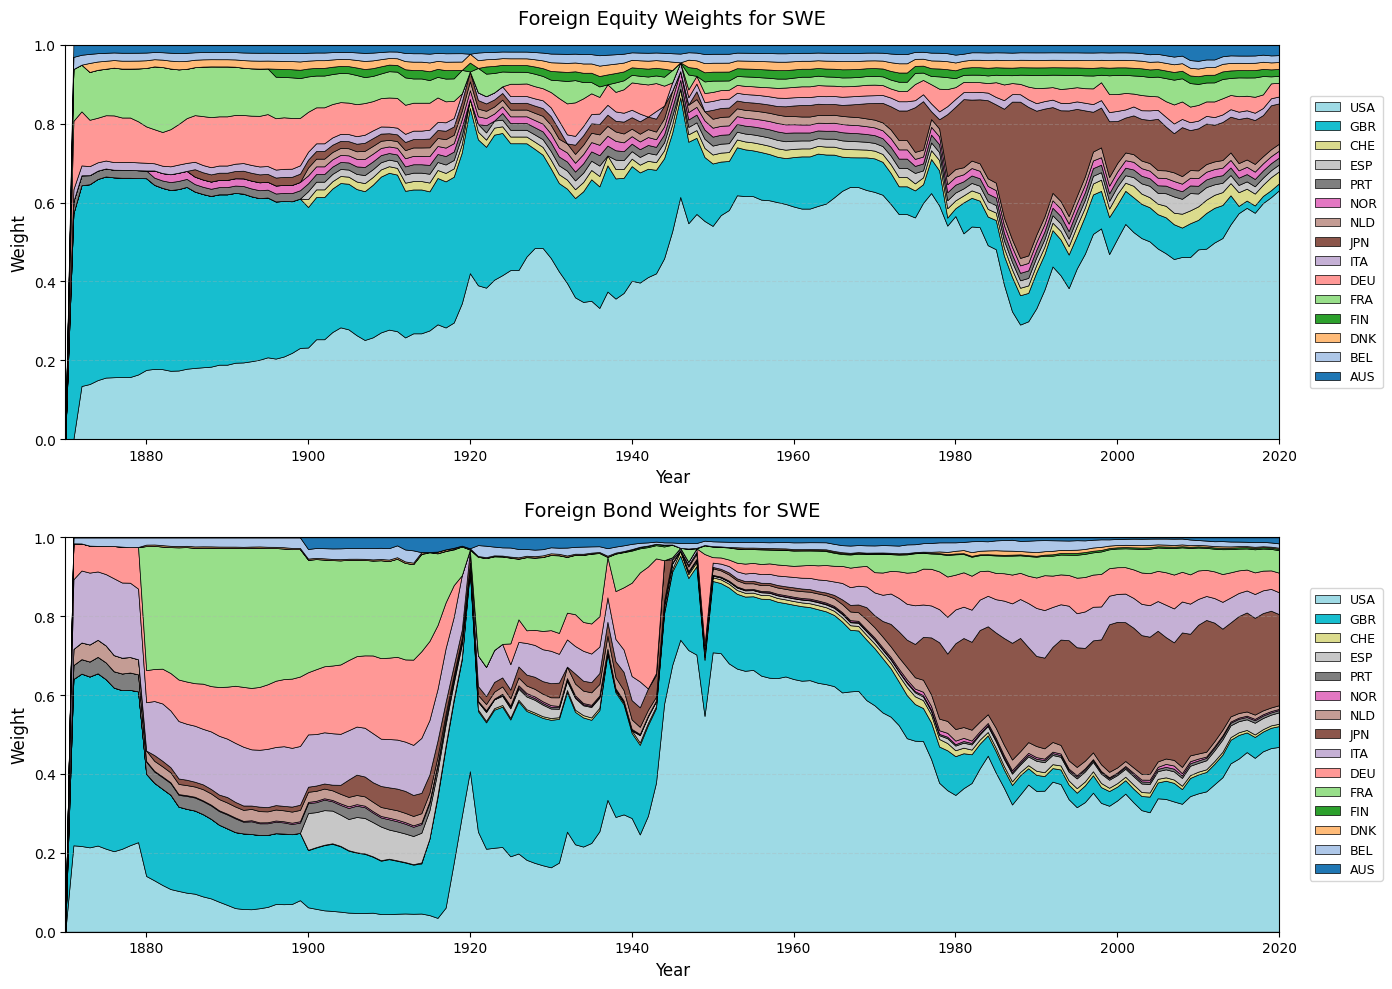


=== Foreign Equity Weight Quality Checks (SWE) ===

1. Yearly weight sums:
   Min: 1.000000
   Max: 1.000000
   Mean: 1.000000
   [OK] All years sum to 1.0

=== Foreign Bond Weight Quality Checks (SWE) ===

1. Yearly weight sums:
   Min: 1.000000
   Max: 1.000000
   Mean: 1.000000
   [OK] All years sum to 1.0


In [ ]:
# Generate country color mapping
colors_map = plt.cm.tab20(np.linspace(0, 1, len(JST_COUNTRIES)))
country_colors = {country: colors_map[i] for i, country in enumerate(JST_COUNTRIES)}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_WEIGHTS)

# Filter for the selected domestic country
iso_domestic = EXAMPLE_DOMESTIC_COUNTRY_1

# ========== EQUITY WEIGHTS (Top Subplot) ==========
domestic_eq_weights = (
    equity_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .select("year", "iso_foreign", "normalized_weight")
    .pivot(index="year", on="iso_foreign", values="normalized_weight")
    .sort("year")
    .fill_null(0)
)

# create a date spine
date_spine = pl.int_range(
    PLOT_YEAR_MIN, PLOT_YEAR_MAX + 1, eager=True
).to_frame(name="year")

# join to ensure all years are present
domestic_eq_weights = date_spine.join(domestic_eq_weights, on="year", how="left").fill_null(0)

# Get all countries present in the data
countries_in_data = [col for col in domestic_eq_weights.columns if col != "year"]

# Sort like the JST_COUNTRIES list, with any missing countries at the end
countries_in_data = sorted(countries_in_data, key=lambda x: -JST_COUNTRIES.index(x) if x in JST_COUNTRIES else len(JST_COUNTRIES))

# Map countries to their colors
colors = [country_colors[country] for country in countries_in_data]

# Create stacked area plot for equity
ax1.stackplot(
    domestic_eq_weights["year"], 
    [domestic_eq_weights[country] for country in countries_in_data],
    labels=countries_in_data,
    colors=colors,
    edgecolor='black',
    linewidth=STACKPLOT_LINE_WIDTH
)

ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=FONTSIZE_LEGEND, ncol=1)
ax1.set_xlabel("Year", fontsize=FONTSIZE_LABEL)
ax1.set_ylabel("Weight", fontsize=FONTSIZE_LABEL)
ax1.set_title(f"Foreign Equity Weights for {iso_domestic}", fontsize=FONTSIZE_TITLE, pad=TITLE_PAD)
ax1.grid(True, alpha=GRID_ALPHA, axis='y', linestyle='--')
ax1.set_ylim(0, 1)
ax1.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)

# ========== BOND WEIGHTS (Bottom Subplot) ==========
domestic_bond_weights = (
    bond_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .select("year", "iso_foreign", "normalized_weight")
    .pivot(index="year", on="iso_foreign", values="normalized_weight")
    .sort("year")
    .fill_null(0)
)

# join to ensure all years are present
domestic_bond_weights = date_spine.join(domestic_bond_weights, on="year", how="left").fill_null(0)

# Get all countries present in the bond data
bond_countries_in_data = [col for col in domestic_bond_weights.columns if col != "year"]

# Sort like the JST_COUNTRIES list, with any missing countries at the end
bond_countries_in_data = sorted(bond_countries_in_data, key=lambda x: -JST_COUNTRIES.index(x) if x in JST_COUNTRIES else len(JST_COUNTRIES))

# Map countries to their colors
bond_colors = [country_colors[country] for country in bond_countries_in_data]

# Create stacked area plot for bonds
ax2.stackplot(
    domestic_bond_weights["year"], 
    [domestic_bond_weights[country] for country in bond_countries_in_data],
    labels=bond_countries_in_data,
    colors=bond_colors,
    edgecolor='black',
    linewidth=STACKPLOT_LINE_WIDTH
)

ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=FONTSIZE_LEGEND, ncol=1)
ax2.set_xlabel("Year", fontsize=FONTSIZE_LABEL)
ax2.set_ylabel("Weight", fontsize=FONTSIZE_LABEL)
ax2.set_title(f"Foreign Bond Weights for {iso_domestic}", fontsize=FONTSIZE_TITLE, pad=TITLE_PAD)
ax2.grid(True, alpha=GRID_ALPHA, axis='y', linestyle='--')
ax2.set_ylim(0, 1)
ax2.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)

plt.tight_layout()
plt.show()

# Quality checks
print(f"\n=== Foreign Equity Weight Quality Checks ({iso_domestic}) ===\n")

yearly_sums = (
    equity_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .group_by("year")
    .agg(pl.col("normalized_weight").sum().alias("total"))
)
print(f"1. Yearly weight sums:")
print(f"   Min: {yearly_sums['total'].min():.6f}")
print(f"   Max: {yearly_sums['total'].max():.6f}")
print(f"   Mean: {yearly_sums['total'].mean():.6f}")

problematic_years = yearly_sums.filter((pl.col("total") < WEIGHT_SUM_TOLERANCE_MIN) | (pl.col("total") > WEIGHT_SUM_TOLERANCE_MAX))
if len(problematic_years) > 0:
    print(f"   WARNING: {len(problematic_years)} years with totals outside [{WEIGHT_SUM_TOLERANCE_MIN}, {WEIGHT_SUM_TOLERANCE_MAX}]")
else:
    print("   [OK] All years sum to 1.0")

print(f"\n=== Foreign Bond Weight Quality Checks ({iso_domestic}) ===\n")

bond_yearly_sums = (
    bond_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .group_by("year")
    .agg(pl.col("normalized_weight").sum().alias("total"))
)
print(f"1. Yearly weight sums:")
print(f"   Min: {bond_yearly_sums['total'].min():.6f}")
print(f"   Max: {bond_yearly_sums['total'].max():.6f}")
print(f"   Mean: {bond_yearly_sums['total'].mean():.6f}")

bond_problematic_years = bond_yearly_sums.filter((pl.col("total") < WEIGHT_SUM_TOLERANCE_MIN) | (pl.col("total") > WEIGHT_SUM_TOLERANCE_MAX))
if len(bond_problematic_years) > 0:
    print(f"   WARNING: {len(bond_problematic_years)} years with totals outside [{WEIGHT_SUM_TOLERANCE_MIN}, {WEIGHT_SUM_TOLERANCE_MAX}]")
else:
    print("   [OK] All years sum to 1.0")

# Calculate Returns

In [59]:
bond_data = bond_universe_weights.join(
    return_data.select(
        "year",
        pl.col("iso").alias("iso_foreign"),
        pl.col("bond_tr").alias("foreign_tr_hedged"),
        pl.col("bond_tr_usd").alias("foreign_tr_usd"),
    ),
    on=["year", "iso_foreign"],
    how="inner",
).join(
    return_data.select(
        "year",
        pl.col("iso").alias("iso_domestic"),
        pl.col("bond_tr").alias("domestic_tr"),
        pl.col("xrusd_return").alias("xrusd_return"),
    ),
    on=["year", "iso_domestic"],
    how="inner",
).with_columns(
    ((1 + pl.col("foreign_tr_usd")) * (1 + pl.col("xrusd_return")) - 1).alias(
        "foreign_tr_unhedged"
    )
).select(
    "year",
    "iso_domestic",
    "iso_foreign",
    "normalized_weight",
    "foreign_tr_hedged",
    "foreign_tr_unhedged",
    "domestic_tr",
).group_by("year", "iso_domestic").agg(
    pl.col("normalized_weight").sum().is_close(1.0).alias("weights_sum_check"),
    (pl.col("normalized_weight") * pl.col("foreign_tr_hedged")).sum().alias("foreign_tr_hedged"),
    (pl.col("normalized_weight") * pl.col("foreign_tr_unhedged")).sum().alias("foreign_tr_unhedged"),
    (pl.col("normalized_weight") * pl.col("domestic_tr")).sum().alias("domestic_tr"),
).with_columns(
    pl.lit("Bonds").alias("asset_class")
)

# Repeat for equities
equity_data = equity_universe_weights.join(
    return_data.select(
        "year",
        pl.col("iso").alias("iso_foreign"),
        pl.col("eq_tr").alias("foreign_tr_hedged"),
        pl.col("eq_tr_usd").alias("foreign_tr_usd"),
    ),
    on=["year", "iso_foreign"],
    how="inner",
).join(
    return_data.select(
        "year",
        pl.col("iso").alias("iso_domestic"),
        pl.col("eq_tr").alias("domestic_tr"),
        pl.col("xrusd_return").alias("xrusd_return"),
    ),
    on=["year", "iso_domestic"],
    how="inner",
).with_columns(
    ((1 + pl.col("foreign_tr_usd")) * (1 + pl.col("xrusd_return")) - 1).alias(
        "foreign_tr_unhedged"
    )
).select(
    "year",
    "iso_domestic",
    "iso_foreign",
    "normalized_weight",
    "foreign_tr_hedged",
    "foreign_tr_unhedged",
    "domestic_tr",
).group_by("year", "iso_domestic").agg(
    pl.col("normalized_weight").sum().is_close(1.0).alias("weights_sum_check"),
    (pl.col("normalized_weight") * pl.col("foreign_tr_hedged")).sum().alias("foreign_tr_hedged"),
    (pl.col("normalized_weight") * pl.col("foreign_tr_unhedged")).sum().alias("foreign_tr_unhedged"),
    (pl.col("normalized_weight") * pl.col("domestic_tr")).sum().alias("domestic_tr"),
).with_columns(
    pl.lit("Equities").alias("asset_class")
)

# bills are only domestic
bills_data = return_data.select(
    "year",
    pl.col("iso").alias("iso_domestic"),
    pl.col("bill_rate").alias("domestic_tr"),
).join(
    domestic_mask.select("year", pl.col("iso").alias("iso_domestic")),
      on=["year", "iso_domestic"], 
      how="inner"
).with_columns(
    pl.lit("Bills").alias("asset_class")
).select(
    "year",
    "iso_domestic",
    pl.lit(True).alias("weights_sum_check"),
    pl.lit(None).cast(pl.Float64).alias("foreign_tr_hedged"),
    pl.lit(None).cast(pl.Float64).alias("foreign_tr_unhedged"),
    "domestic_tr",
    "asset_class"
)

cpi_data = return_data.select(
    "year",
    pl.col("iso").alias("iso_domestic"),
    pl.col("cpi_return").alias("domestic_tr"),
).join(
    domestic_mask.select("year", pl.col("iso").alias("iso_domestic")),
      on=["year", "iso_domestic"], 
      how="inner"
).with_columns(
    pl.lit("CPI").alias("asset_class")
).select(
    "year",
    "iso_domestic",
    pl.lit(True).alias("weights_sum_check"),
    pl.lit(None).cast(pl.Float64).alias("foreign_tr_hedged"),
    pl.lit(None).cast(pl.Float64).alias("foreign_tr_unhedged"),
    "domestic_tr",
    "asset_class"
)
# Combine all asset classes
combined_data = pl.concat([equity_data, bond_data, bills_data, cpi_data], how="vertical")



# Summary Statistics

In [ ]:
# summary stats for each country and asset class
summary_stats = combined_data.group_by("iso_domestic", "asset_class").agg(
    pl.col("weights_sum_check").all().alias("weights_sum_check"),
    pl.col("foreign_tr_hedged").mean().alias("foreign_tr_hedged_mean"),
    pl.col("foreign_tr_hedged").std().alias("foreign_tr_hedged_std"),
    pl.col("foreign_tr_unhedged").mean().alias("foreign_tr_unhedged_mean"),
    pl.col("foreign_tr_unhedged").std().alias("foreign_tr_unhedged_std"),
    pl.col("domestic_tr").mean().alias("domestic_tr_mean"),
    pl.col("domestic_tr").std().alias("domestic_tr_std"),
).sort(["iso_domestic", "asset_class"])
# Save the combined data
combined_data.write_csv(OUTPUT_COMBINED_RETURN_DATA_PATH)
summary_stats.write_csv(OUTPUT_SUMMARY_STATS_PATH)

# Visualize Cumulative Returns

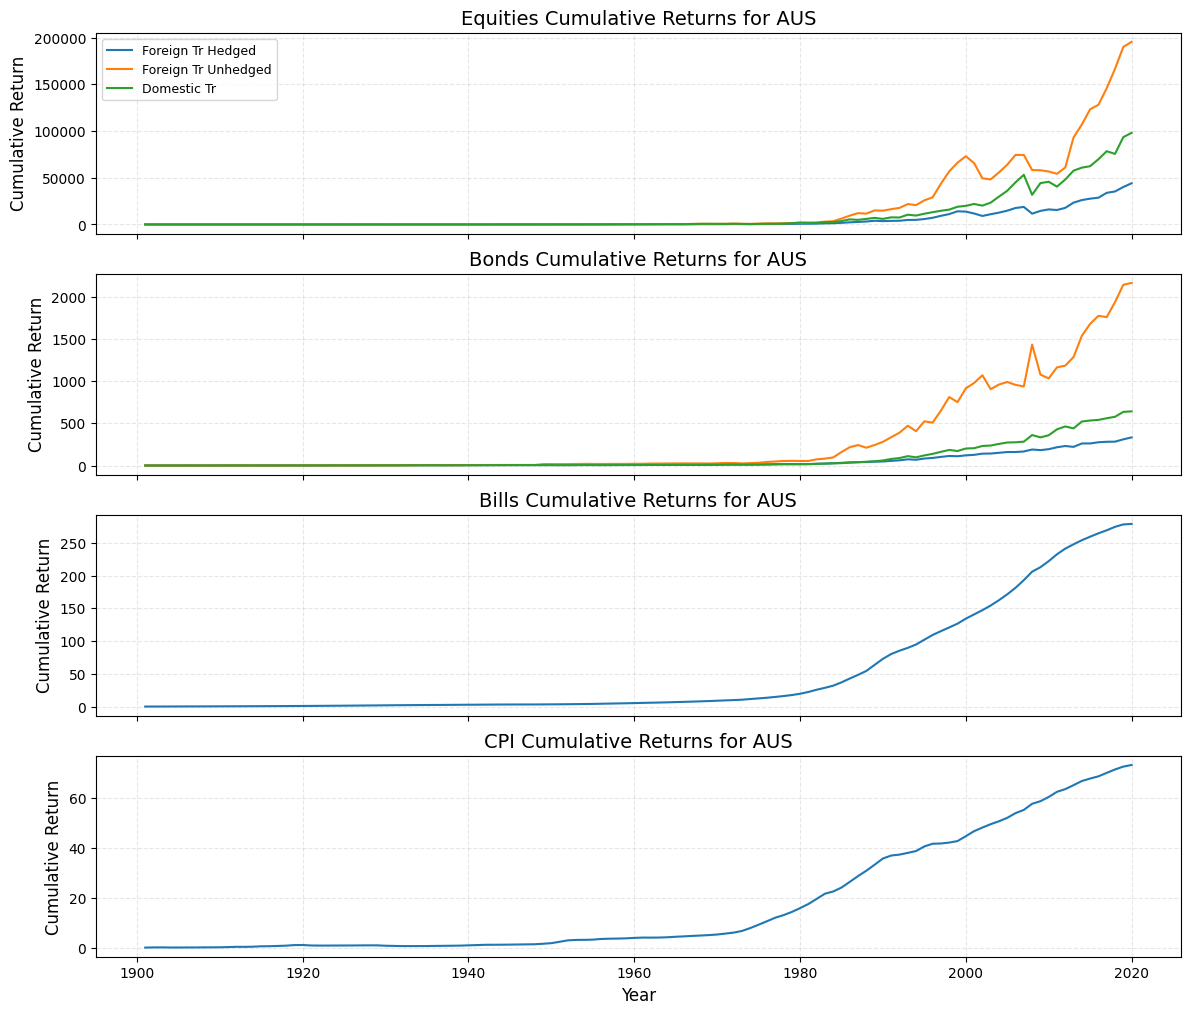

In [ ]:
# plot the cum returns for the combined data for a single country

iso_domestic = EXAMPLE_DOMESTIC_COUNTRY_2

this_country_data = combined_data.filter(pl.col("iso_domestic") == iso_domestic).sort("year").filter(pl.col("year") > FILTER_YEAR_MIN)

fig, axes = plt.subplots(len(ASSET_CLASSES), 1, figsize=FIGSIZE_CUM_RETURNS, sharex=True)

for i, asset_class in enumerate(ASSET_CLASSES):
    asset_data = this_country_data.filter(pl.col("asset_class") == asset_class)

    asset_data = asset_data.with_columns(
        *[
            ((pl.col(subtype).fill_null(0) + 1).cum_prod() - 1).alias(f"{subtype}_cum")
            for subtype in RETURN_SUBTYPES
        ]
    )
    
    for return_type in RETURN_SUBTYPES:
        if asset_data.select(return_type).drop_nulls().height > 0:
            axes[i].plot(
                asset_data["year"],
                asset_data[f"{return_type}_cum"],
                label=return_type.replace("_", " ").title()
            )
            
    axes[i].set_title(f"{asset_class} Cumulative Returns for {iso_domestic}", fontsize=FONTSIZE_TITLE)
    axes[i].set_ylabel("Cumulative Return", fontsize=FONTSIZE_LABEL)
    axes[i].grid(True, alpha=GRID_ALPHA, linestyle='--')
axes[-1].set_xlabel("Year", fontsize=FONTSIZE_LABEL)
axes[0].legend(loc="upper left", fontsize=FONTSIZE_LEGEND)

# Apply Asset Class Configurations

In [ ]:
import yaml

with open(INPUT_ASSET_CLASS_CONFIGS_PATH, "r") as f:
    asset_class_configs = yaml.safe_load(f)

asset_class_configs = pl.DataFrame(asset_class_configs['asset_classes'])


In [ ]:
combined_data.join(
    asset_class_configs.rename({"name": "asset_class"}),
    on="asset_class",
).with_columns(
    (
        pl.col("foreign_tr_hedged") * pl.col("hedging_ratio")
        + pl.col("foreign_tr_unhedged") * (1 - pl.col("hedging_ratio"))
    ).alias("foreign_tr")
).with_columns(
    (
        pl.col("foreign_tr").fill_null(0) * (1 - pl.col("home_bias"))
        + pl.col("domestic_tr").fill_null(0) * pl.col("home_bias")
    ).alias("return")
).select(
    "year",
    "iso_domestic",
    "asset_class",
    "return"
).write_csv(OUTPUT_ASSET_CLASS_RETURNS_PATH)

In [64]:
combined_data

year,iso_domestic,weights_sum_check,foreign_tr_hedged,foreign_tr_unhedged,domestic_tr,asset_class
i64,str,bool,f64,f64,f64,str
1903,"""BEL""",true,-0.002185,-0.01394,0.119176,"""Equities"""
1943,"""BEL""",true,0.179808,0.173653,-0.087336,"""Equities"""
1904,"""JPN""",true,0.157415,0.167773,0.013822,"""Equities"""
2007,"""DEU""",true,0.060623,-0.008501,0.204231,"""Equities"""
1918,"""NOR""",true,0.178907,0.373059,-0.05289,"""Equities"""
…,…,…,…,…,…,…
1894,"""USA""",true,null,null,-0.046299,"""CPI"""
1895,"""USA""",true,null,null,-0.019372,"""CPI"""
1896,"""USA""",true,null,null,0.0,"""CPI"""
